Vincent Cohen

DSCI 551

3/6/26

# <center> Homework 3: **Data Modeling & SQL**
---
## 1. Data Modeling (world)

### a. CREATE TABLE statements
Based on the keys and foreign keys implied by the schema constraints:

```sql
CREATE TABLE language (
    id VARCHAR(2) PRIMARY KEY,
    name VARCHAR(50)
);

CREATE TABLE country (
    code VARCHAR(3) PRIMARY KEY,
    name VARCHAR(50),
    continent VARCHAR(50),
    gnp DECIMAL(10,2)
);

CREATE TABLE city (
    id INT PRIMARY KEY,
    name VARCHAR(50),
    countrycode VARCHAR(3) NOT NULL,
    population INT,
    FOREIGN KEY (countrycode) REFERENCES country(code)
);

CREATE TABLE countrylanguage (
    countrycode VARCHAR(3),
    language_id VARCHAR(2),
    isofficial BOOLEAN,
    percentage DECIMAL(5,2),
    PRIMARY KEY (countrycode, language_id),
    FOREIGN KEY (countrycode) REFERENCES country(code),
    FOREIGN KEY (language_id) REFERENCES language(id)
);
```

### b. ER Model Reverse-Engineering
**Entities & Attributes:**
* **Country**: Attributes: `code` (Primary Key), `name`, `continent`, `gnp`.
* **City**: Attributes: `id` (Primary Key), `name`, `population`.
* **Language**: Attributes: `id` (Primary Key), `name`.

**Relationships & Multiplicity:**
* **Has_City** (Relationship between Country and City):
    * One-to-Many.
    * A Country has *many* Cities.
    * A City belongs to *exactly one* Country (since `countrycode` cannot be null).
* **Speaks_Language** (Relationship between Country and Language, derived from `countrylanguage`):
    * Many-to-Many.
    * A Country speaks *many* Languages, and a Language is spoken in *many* Countries.
    * Relationship Attributes: `isofficial`, `percentage`.

---
## 2. Parent-Child Schema Analysis (Sakila)

### Q1: Parent Reference Count
```sql
SELECT parent_table, COUNT(*) AS reference_count
FROM child_parent
GROUP BY parent_table
ORDER BY reference_count DESC;
```
**Query Result:**
*(Paste MySQL results here)*

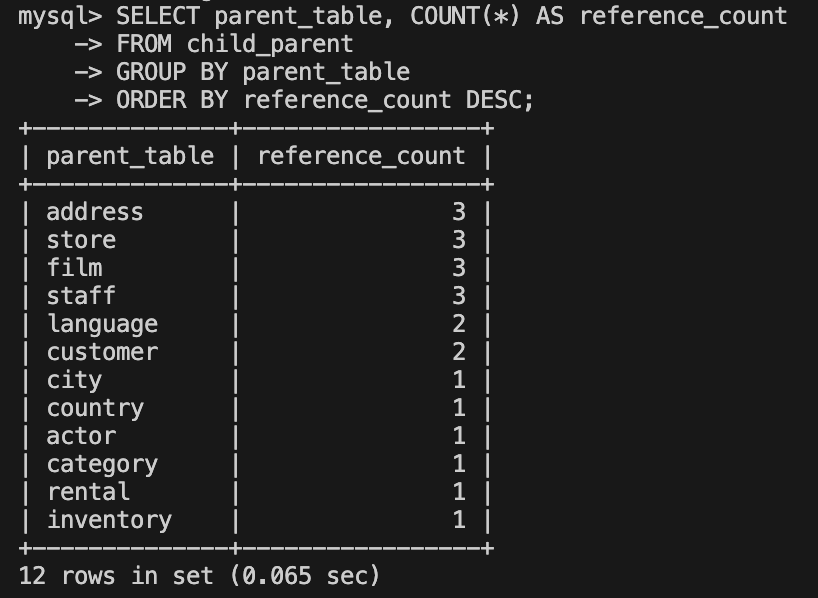

### Q2: Child Dependency Count
```sql
SELECT child_table, COUNT(DISTINCT parent_table) AS dependency_count
FROM child_parent
GROUP BY child_table
HAVING COUNT(DISTINCT parent_table) > 1
ORDER BY dependency_count DESC;
```
**Query Result:**
*(Paste MySQL results here)*

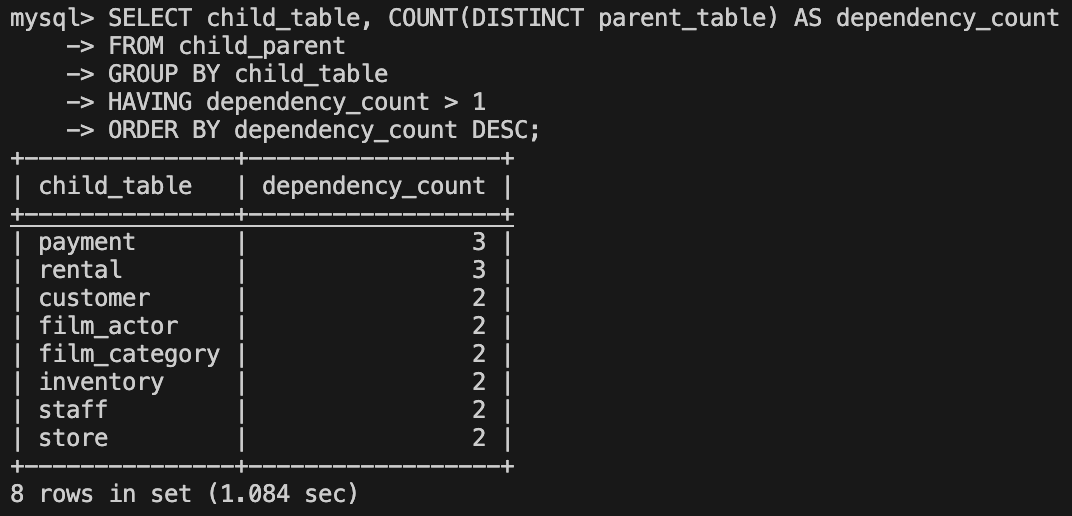

### Q3: Tables Acting as Both Parent and Child
**Solution 1 (JOIN):**
```sql
SELECT DISTINCT p1.parent_table AS table_name
FROM child_parent p1
JOIN child_parent p2 ON p1.parent_table = p2.child_table
ORDER BY table_name ASC;
```
**Solution 2 (INTERSECT):**
```sql
SELECT parent_table AS table_name FROM child_parent
INTERSECT
SELECT child_table AS table_name FROM child_parent
ORDER BY table_name ASC;
```
**Query Result:**
*(Paste MySQL results here)*

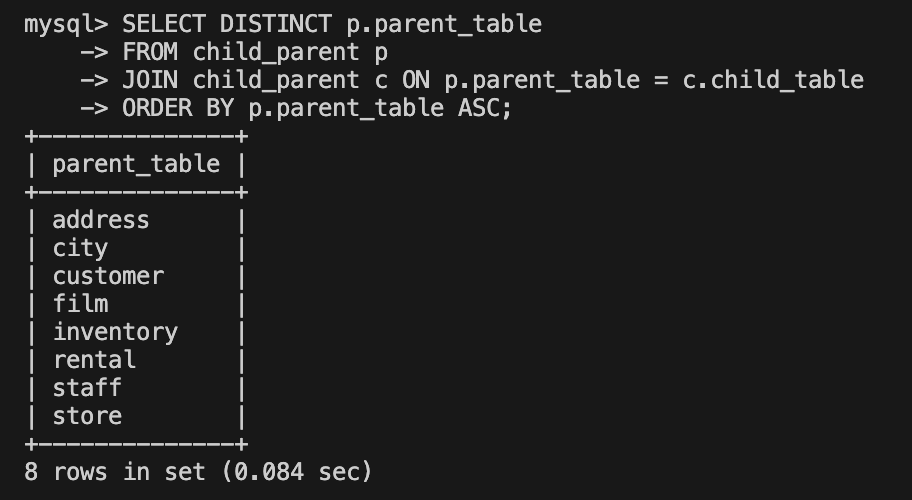

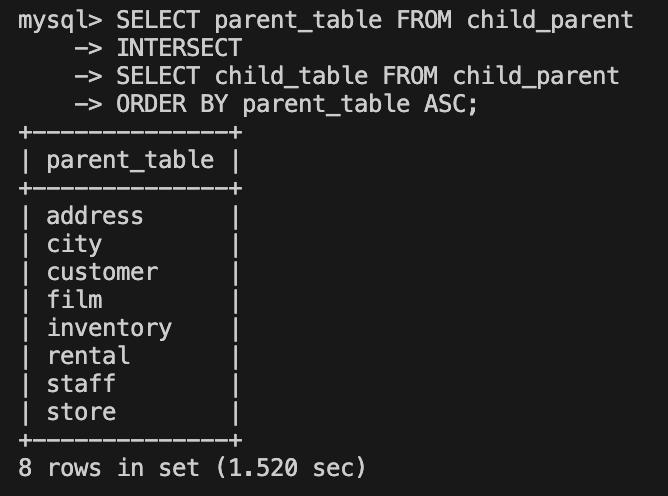

### Q4: Tables With No Relationships
**Solution 1 (LEFT JOIN):**
```sql
SELECT DISTINCT t.TABLE_NAME
FROM tbl_columns t
LEFT JOIN child_parent c ON t.TABLE_NAME = c.child_table
LEFT JOIN child_parent p ON t.TABLE_NAME = p.parent_table
WHERE c.child_table IS NULL AND p.parent_table IS NULL;
```
**Solution 2 (EXCEPT):**
```sql
SELECT TABLE_NAME FROM tbl_columns
EXCEPT
SELECT child_table FROM child_parent
EXCEPT
SELECT parent_table FROM child_parent;
```
**Query Result:**
*(Paste MySQL results here)*

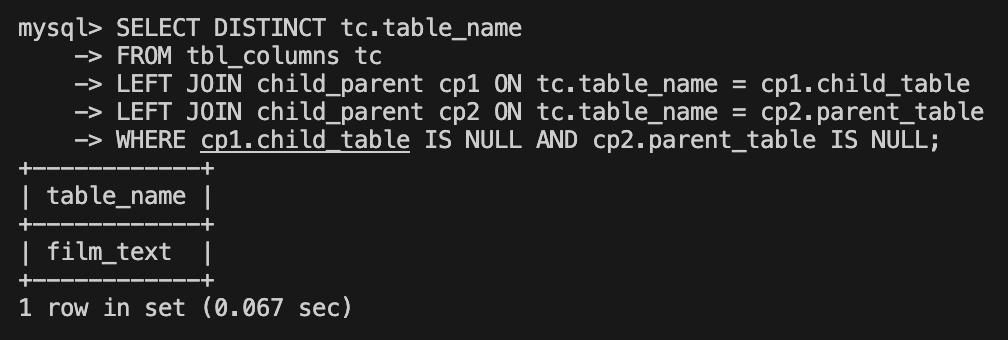

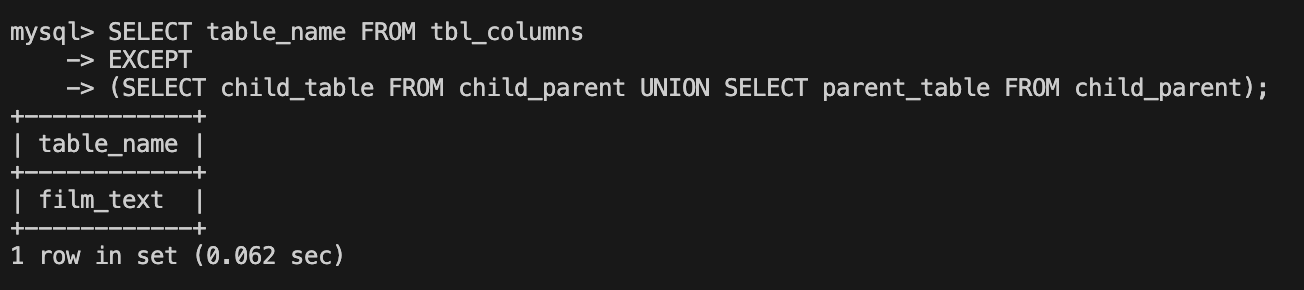

### Q5: Multi-Dependence Detection
```sql
SELECT child_table, parent_table, COUNT(child_col) AS number_of_columns_used
FROM child_parent
GROUP BY child_table, parent_table
HAVING COUNT(child_col) > 1;
```
**Query Result:**
*(Paste MySQL results here)*

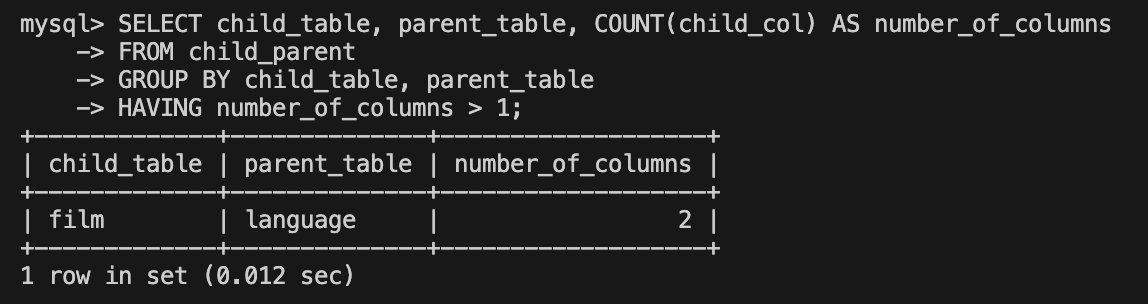

### Q6: Foreign Key Data Type Comparison
```sql
SELECT cp.child_table, cp.child_col, tc.DATA_TYPE AS child_data_type,
       cp.parent_table, cp.parent_col, tp.DATA_TYPE AS parent_data_type
FROM child_parent cp
JOIN tbl_columns tc ON cp.child_table = tc.TABLE_NAME AND cp.child_col = tc.COLUMN_NAME
JOIN tbl_columns tp ON cp.parent_table = tp.TABLE_NAME AND cp.parent_col = tp.COLUMN_NAME;
```
**Query Result:**
*(Paste MySQL results here)*

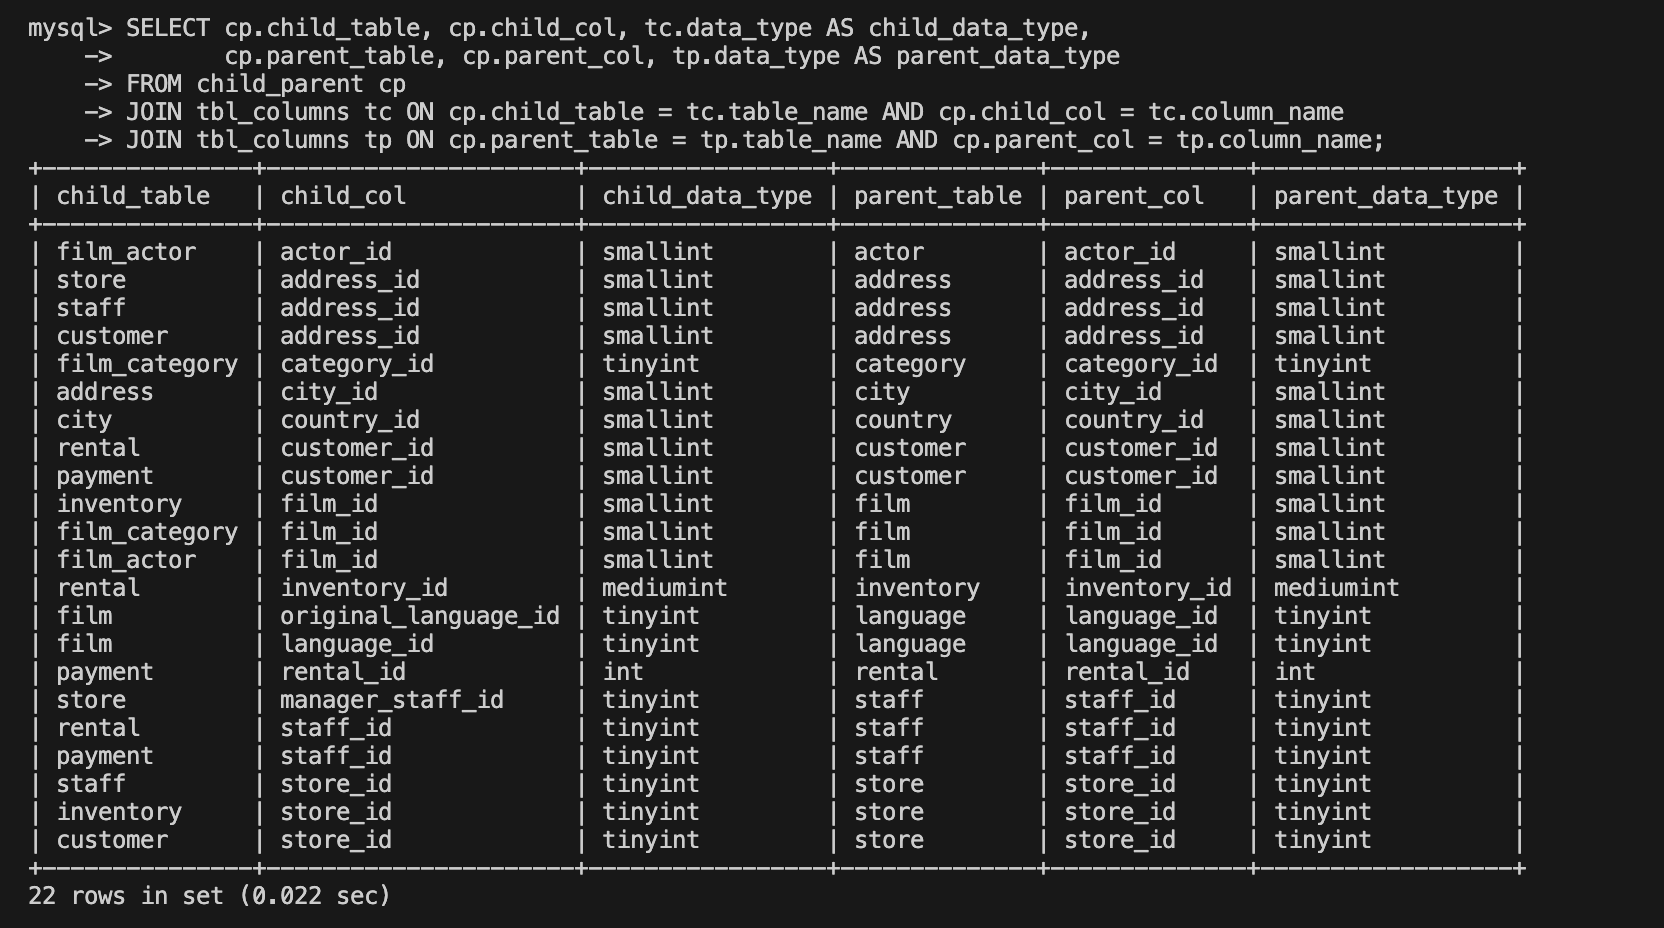

### Q7: Most Common Foreign Key Data Types
```sql
WITH FK_Types AS (
    SELECT tc.DATA_TYPE
    FROM child_parent cp
    JOIN tbl_columns tc ON cp.child_table = tc.TABLE_NAME AND cp.child_col = tc.COLUMN_NAME
),
TypeCounts AS (
    SELECT DATA_TYPE, COUNT(*) as occurrence_count
    FROM FK_Types
    GROUP BY DATA_TYPE
)
SELECT DATA_TYPE, occurrence_count
FROM TypeCounts
WHERE occurrence_count = (SELECT MAX(occurrence_count) FROM TypeCounts);
```
**Query Result:**
*(Paste MySQL results here)*

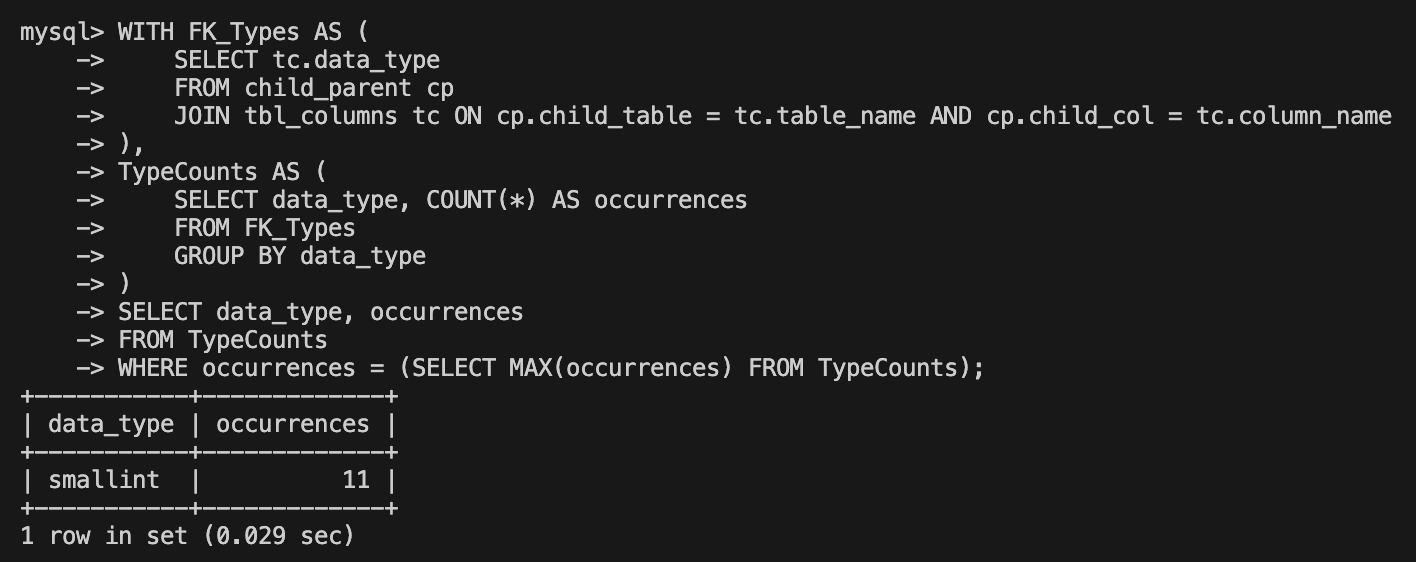

### Q8: Connectivity Score
```sql
WITH ParentCounts AS (
    SELECT parent_table AS tbl, COUNT(*) AS p_count FROM child_parent GROUP BY parent_table
),
ChildCounts AS (
    SELECT child_table AS tbl, COUNT(*) AS c_count FROM child_parent GROUP BY child_table
),
AllTables AS (
    SELECT DISTINCT TABLE_NAME AS tbl FROM tbl_columns
)
SELECT a.tbl AS table_name,
       (COALESCE(p.p_count, 0) + COALESCE(c.c_count, 0)) AS connectivity_score
FROM AllTables a
LEFT JOIN ParentCounts p ON a.tbl = p.tbl
LEFT JOIN ChildCounts c ON a.tbl = c.tbl
ORDER BY connectivity_score DESC;
```
**Query Result:**
*(Paste MySQL results here)*

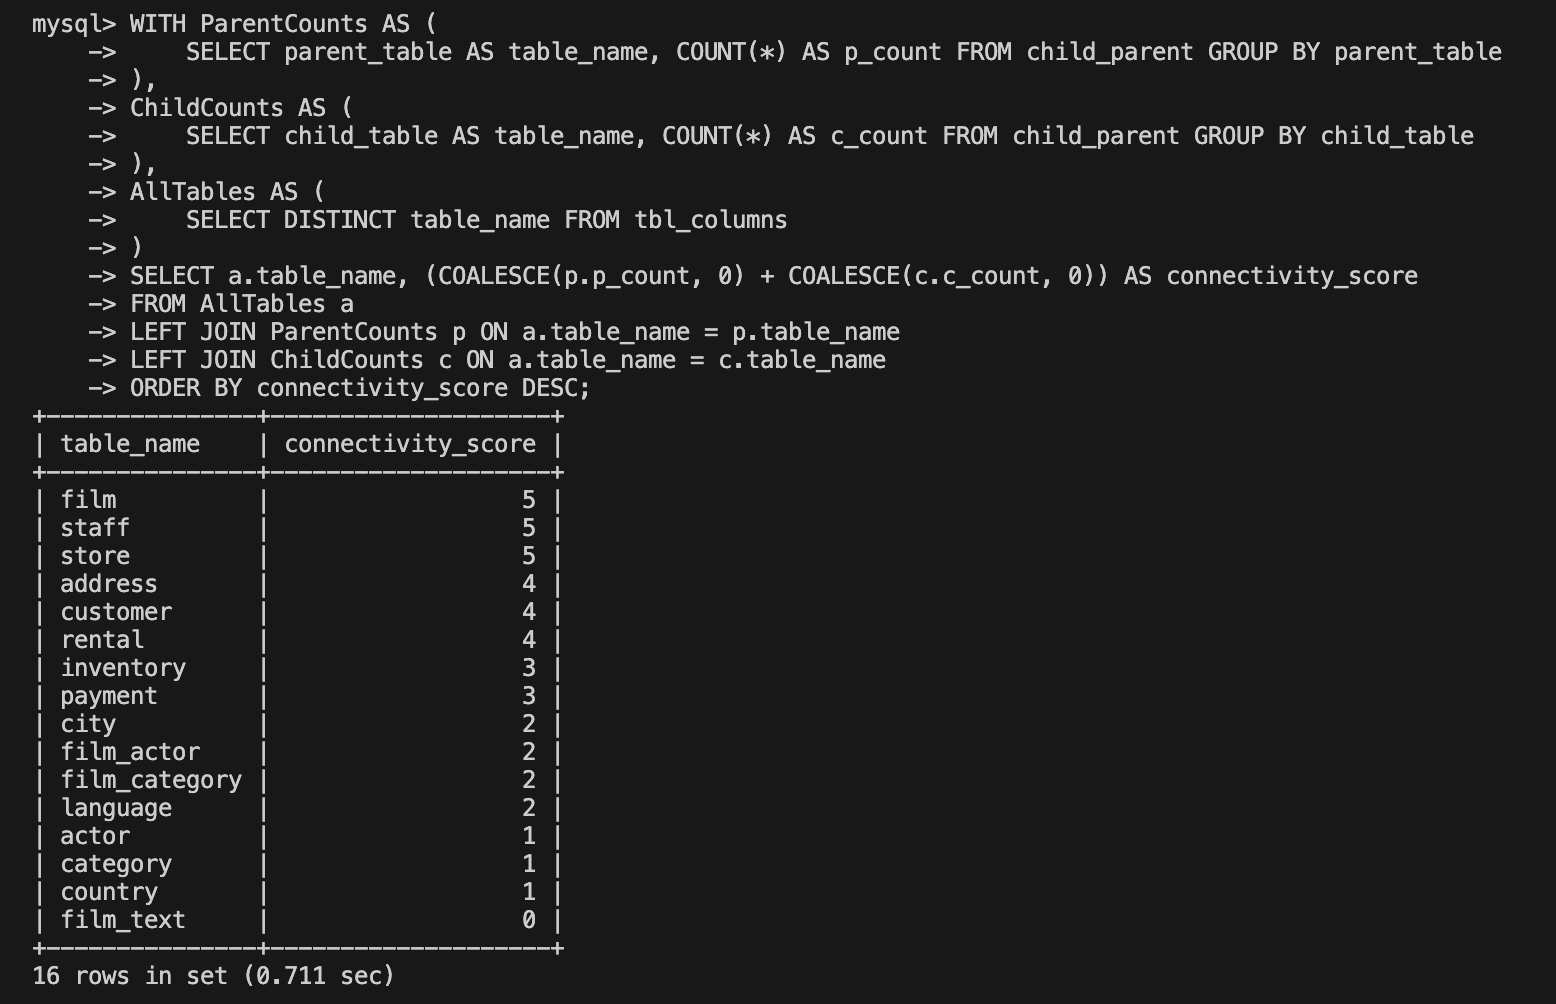

### Q9: Tables With Above-Average Connectivity
```sql
-- Create the view first
CREATE VIEW tbl_score AS
WITH ParentCounts AS (
    SELECT parent_table AS tbl, COUNT(*) AS p_count FROM child_parent GROUP BY parent_table
),
ChildCounts AS (
    SELECT child_table AS tbl, COUNT(*) AS c_count FROM child_parent GROUP BY child_table
),
AllTables AS (
    SELECT DISTINCT TABLE_NAME AS tbl FROM tbl_columns
)
SELECT a.tbl AS table_name,
       (COALESCE(p.p_count, 0) + COALESCE(c.c_count, 0)) AS connectivity_score
FROM AllTables a
LEFT JOIN ParentCounts p ON a.tbl = p.tbl
LEFT JOIN ChildCounts c ON a.tbl = c.tbl;

-- Subquery to find above-average connectivity
SELECT table_name
FROM tbl_score
WHERE connectivity_score > (SELECT AVG(connectivity_score) FROM tbl_score);
```
**Query Result:**
*(Paste MySQL results here)*

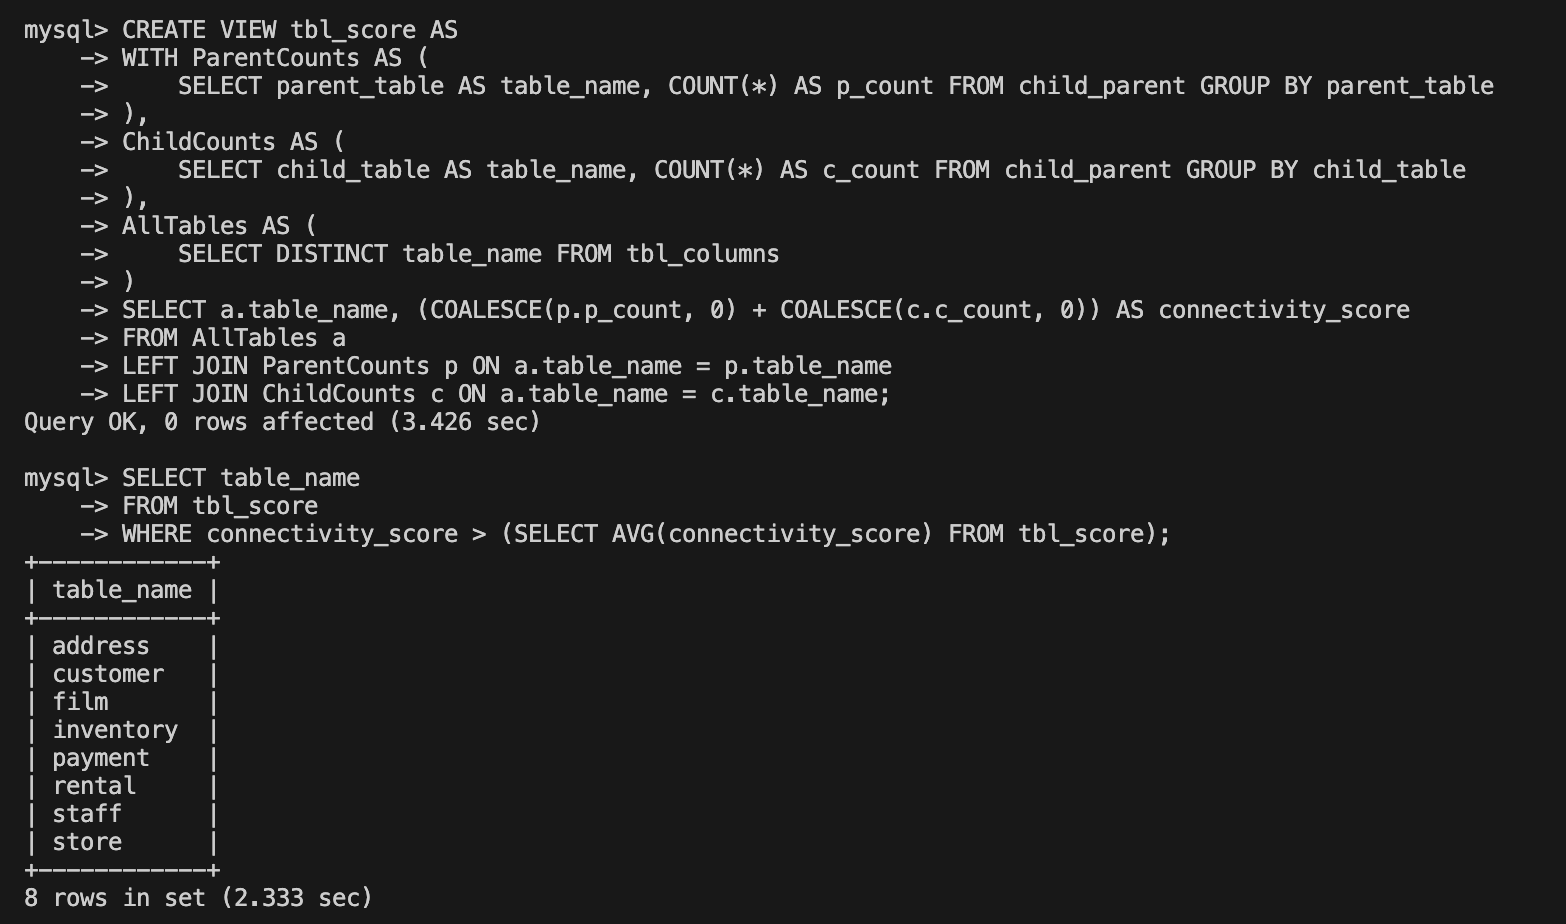

### Q10: Tables with Relationships and > 5 Columns
```sql
SELECT t.TABLE_NAME, COUNT(t.COLUMN_NAME) AS column_count
FROM tbl_columns t
WHERE t.TABLE_NAME IN (SELECT child_table FROM child_parent)
   OR t.TABLE_NAME IN (SELECT parent_table FROM child_parent)
GROUP BY t.TABLE_NAME
HAVING COUNT(t.COLUMN_NAME) > 5
ORDER BY column_count DESC;
```
**Query Result:**
*(Paste MySQL results here)*

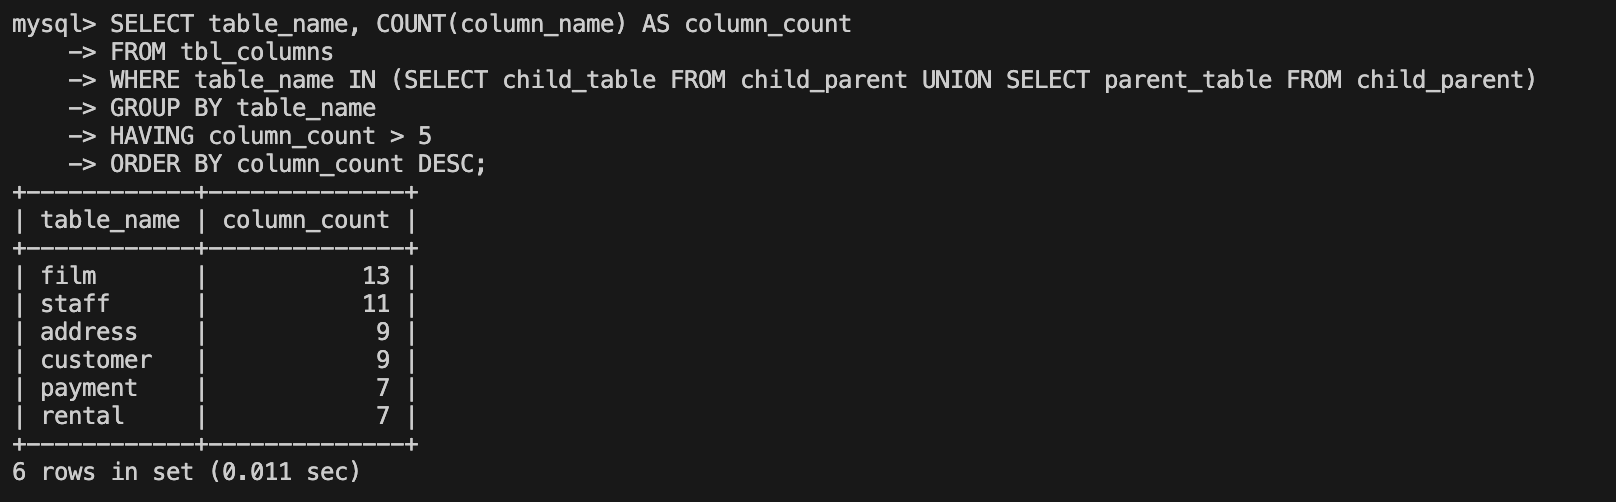